# Notebook for visualizing the different datasets

In [7]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from script import data_visualization as dv
from script import data_preprocessing as dp

In [8]:
df_data1 = dp.load_data()
df_data2 = dp.load_data(path='../data/raw_data/data2/*.csv')
df_data3 = dp.load_data(path='../data/raw_data/data3/*.csv')
df_data4 = dp.load_data(path='../data/raw_data/data4/*.csv')
df_data5 = dp.load_data(path='../data/raw_data/data5/*.csv')
df_data6 = dp.load_data(path='../data/raw_data/data6/*.csv')
df_data7 = dp.load_data(path='../data/raw_data/data7/*.csv')
df_data8 = dp.load_data(path='../data/raw_data/data8/*.csv')
df_data9 = dp.load_data(path='../data/raw_data/data9/*.csv')
df_data10 = dp.load_data(path='../data/raw_data/data10/*.csv')
df_data11 = dp.load_data(path='../data/raw_data/data11/*.csv')
df_data12 = dp.load_data(path='../data/raw_data/data12/*.csv')

datasets = {
    "data1": df_data1,
    "data2": df_data2,
    "data3": df_data3,
    "data4": df_data4,
    "data5": df_data5,
    "data6": df_data6,
    "data7": df_data7,
    "data8": df_data8,
    "data9": df_data9,
    "data10": df_data10,
    "data11": df_data11,
    "data12": df_data12,
}

In [9]:
for dataset in datasets.values():
    dp.create_target_column(dataset)
    dp.create_future_target(dataset)

⚙️ Flow threshold set to: 327.32
⚙️ Flow threshold set to: 346.84
⚙️ Flow threshold set to: 1128.58
⚙️ Flow threshold set to: 0.68
⚙️ Flow threshold set to: 846.75
⚙️ Flow threshold set to: 1797.59
⚙️ Flow threshold set to: 747.08
⚙️ Flow threshold set to: 0.84
⚙️ Flow threshold set to: 0.76
⚙️ Flow threshold set to: 0.73
⚙️ Flow threshold set to: 3.30
⚙️ Flow threshold set to: 1.33


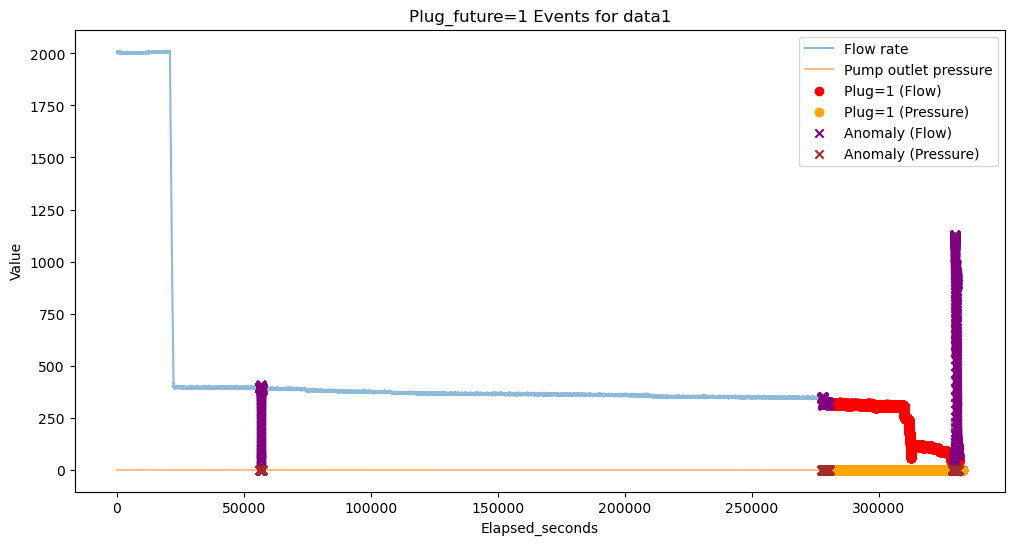

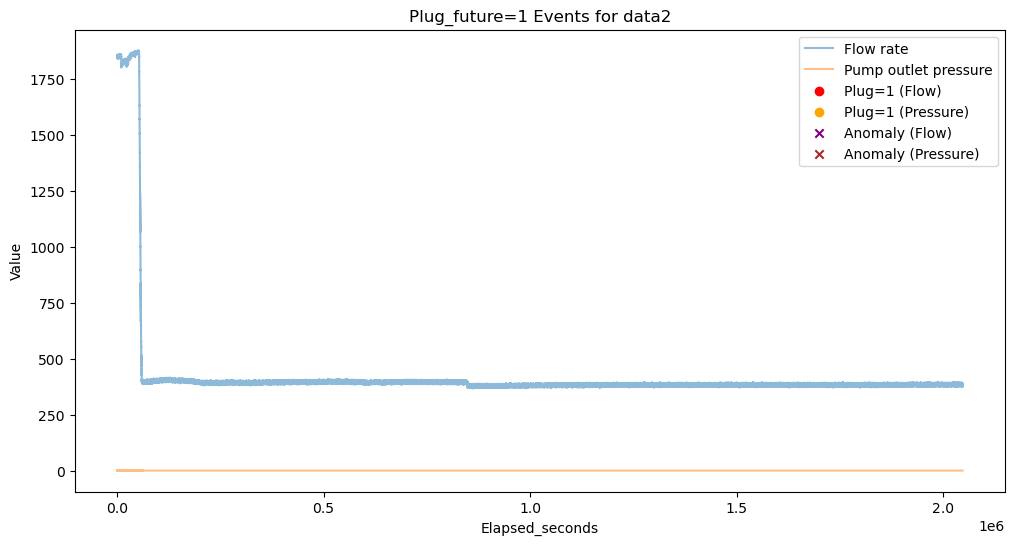

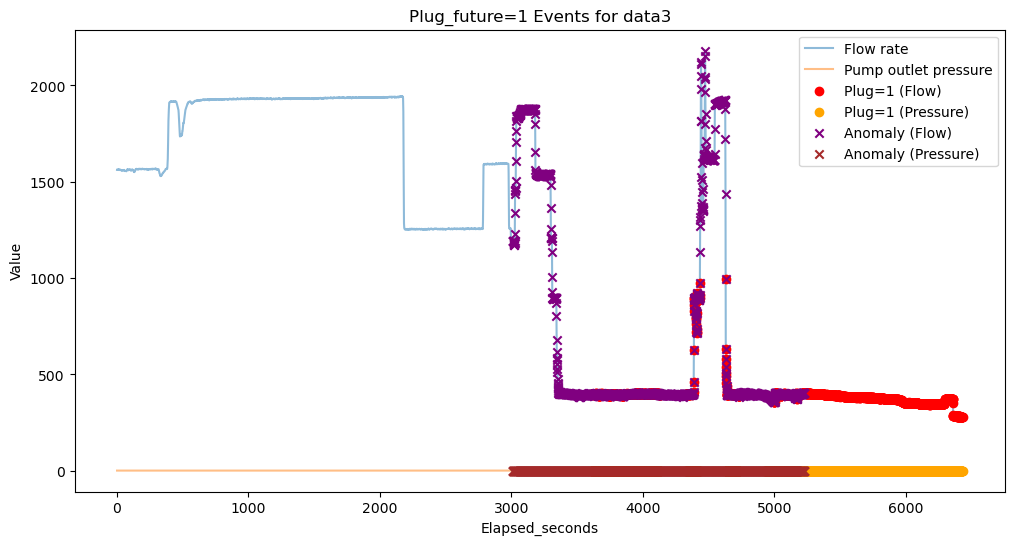

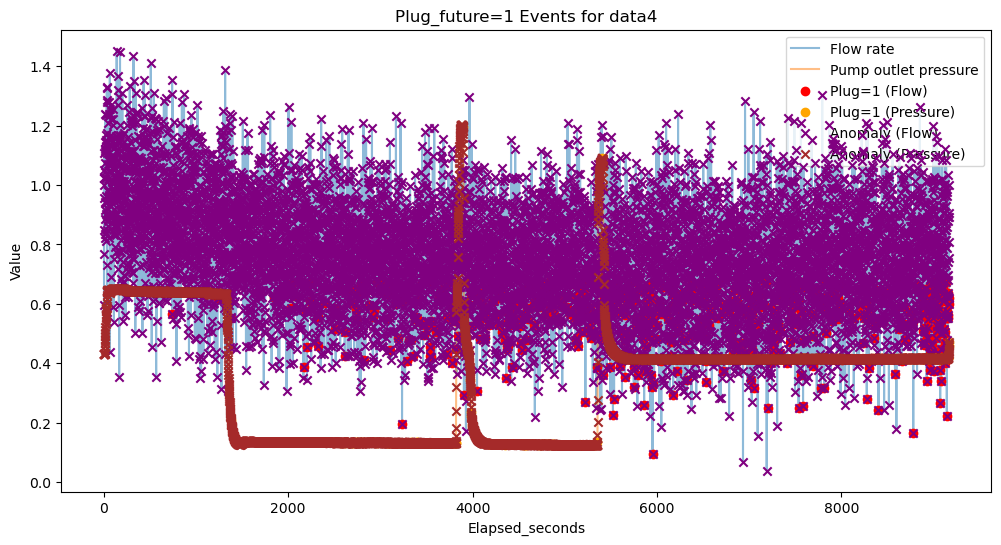

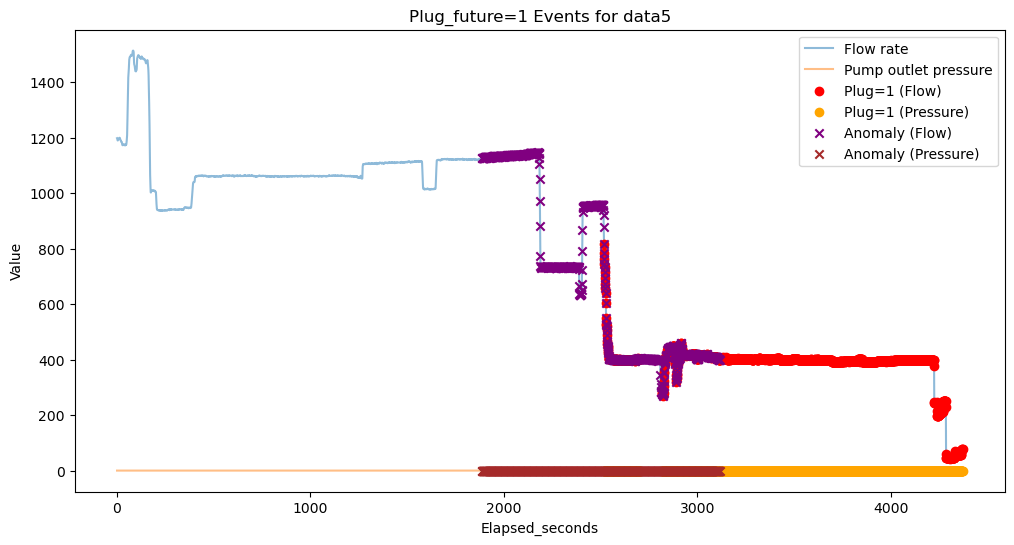

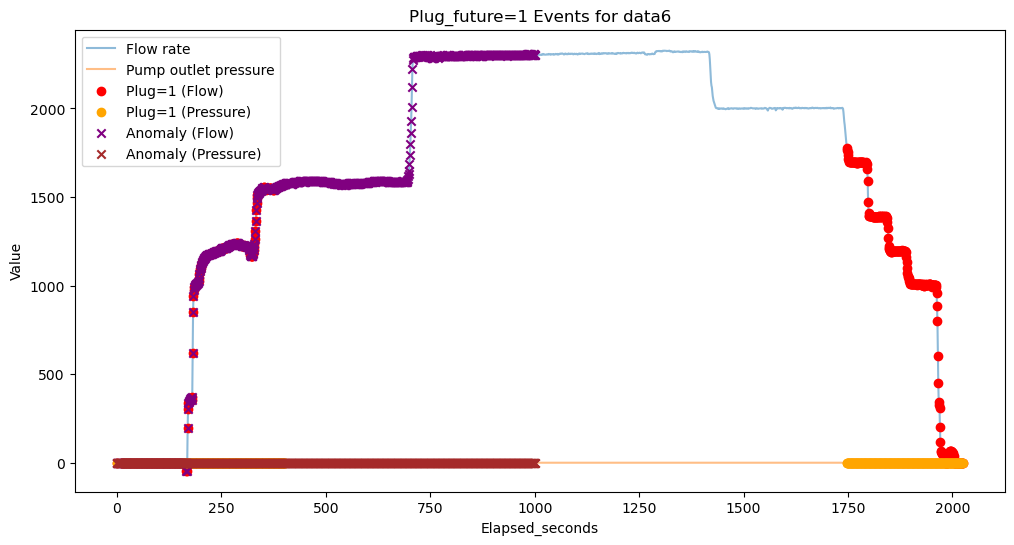

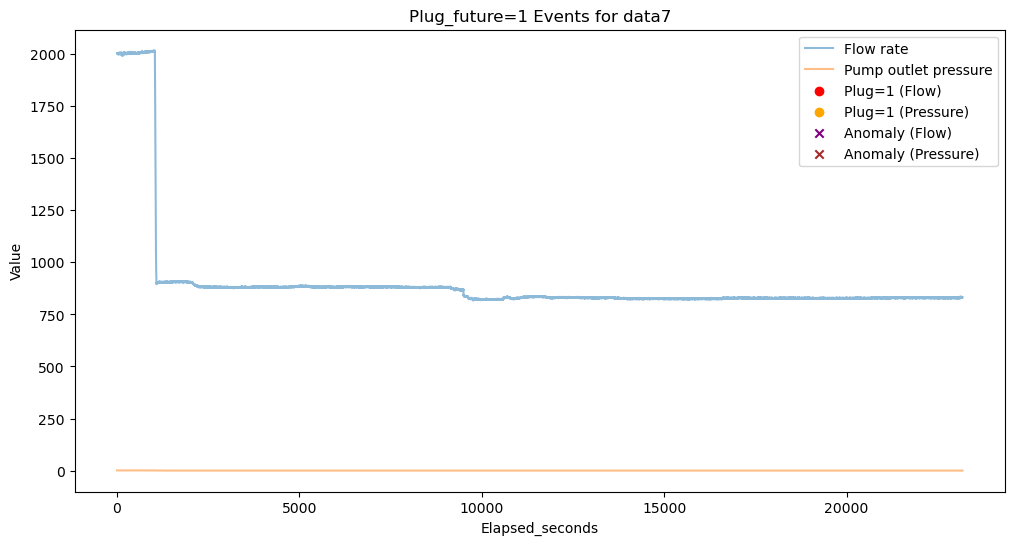

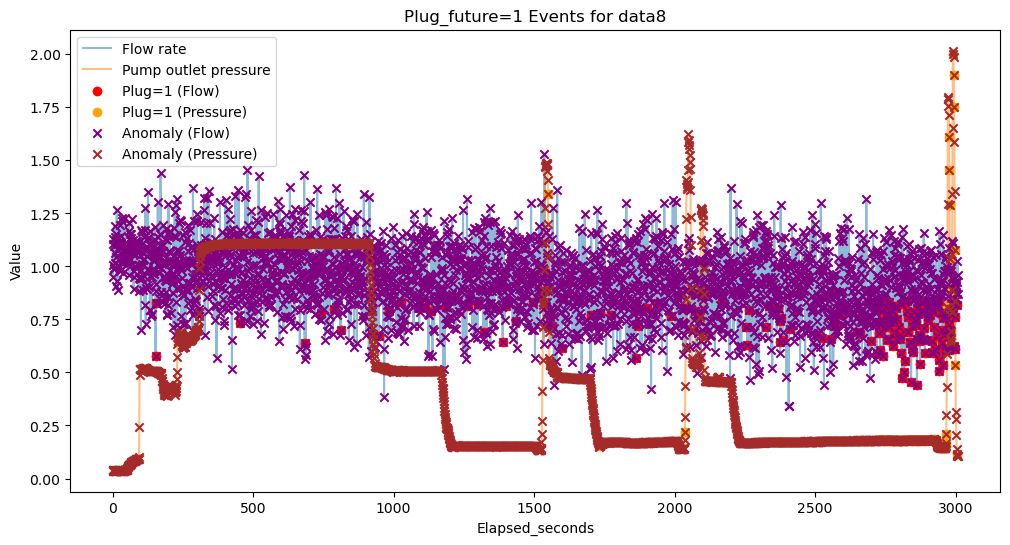

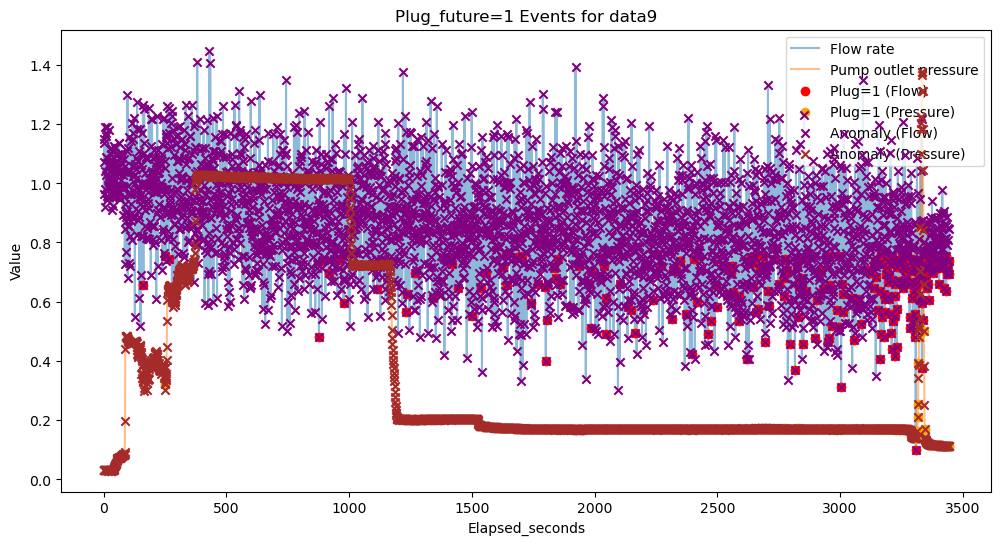

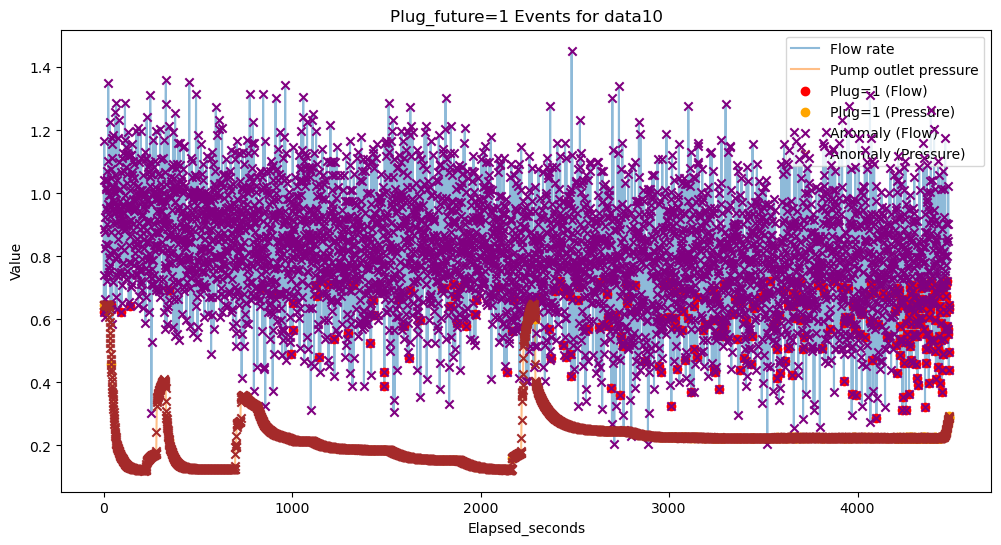

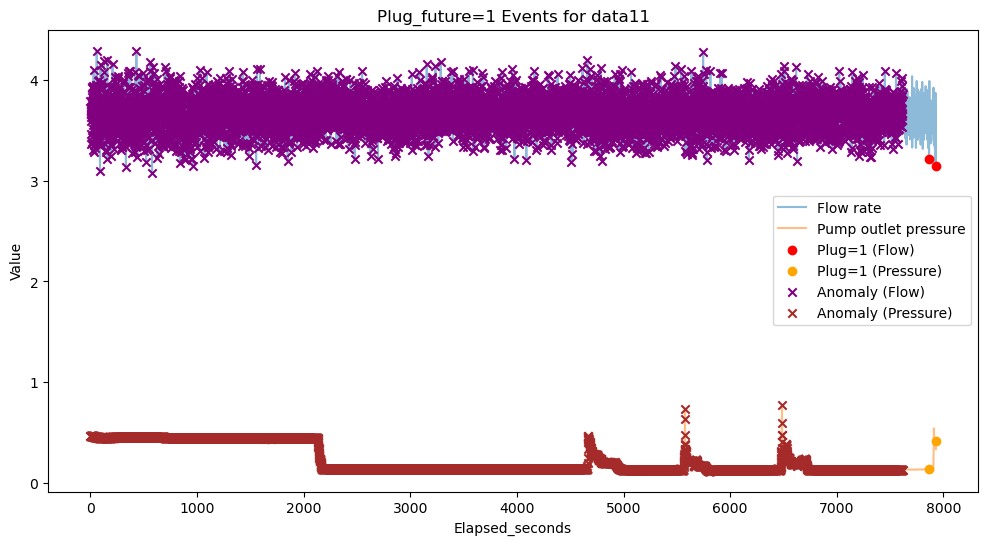

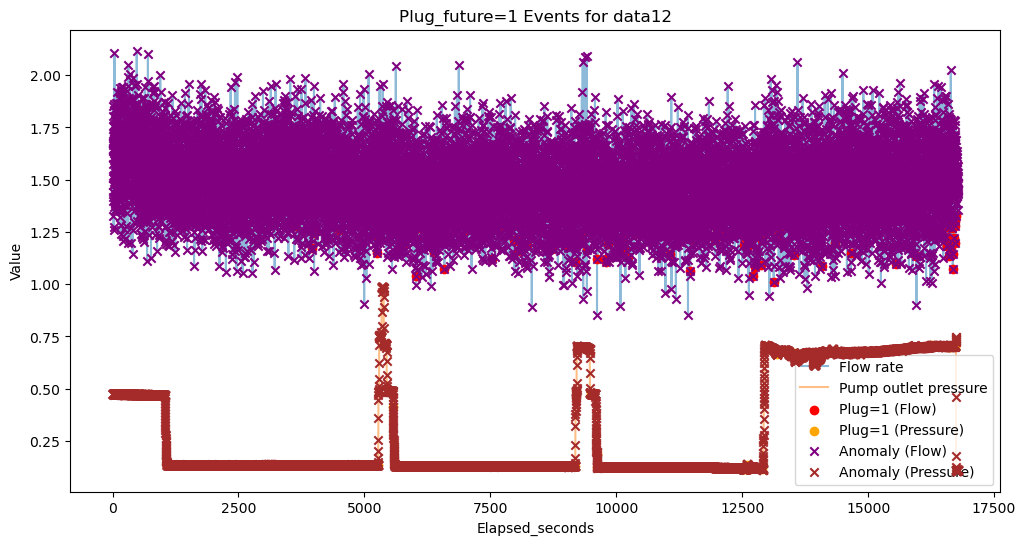

In [10]:
for key, dataset in datasets.items():
    dv.visualize_plug_event(dataset, anomalies=True, name=key)

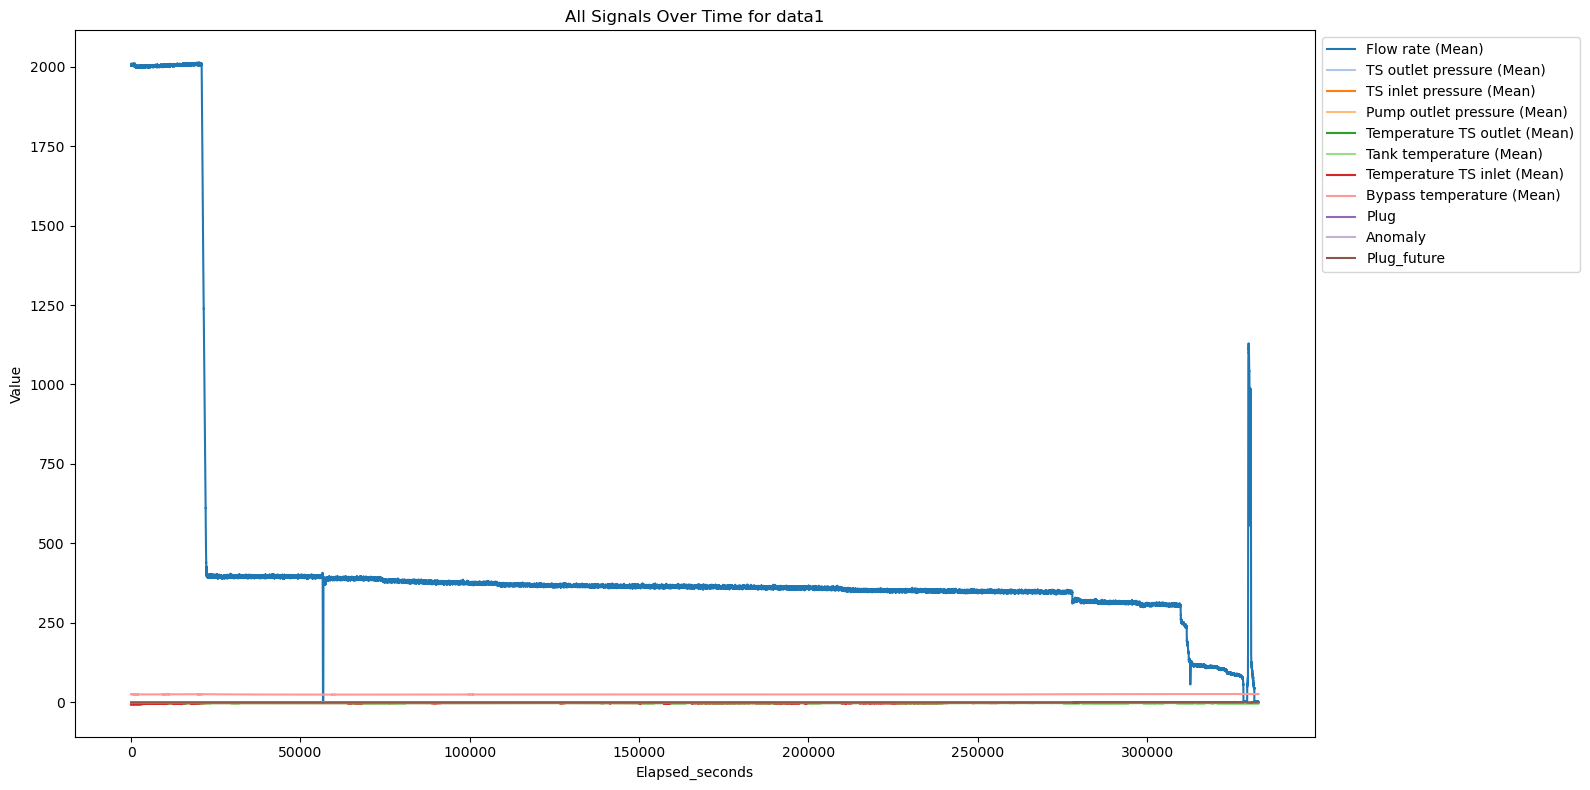

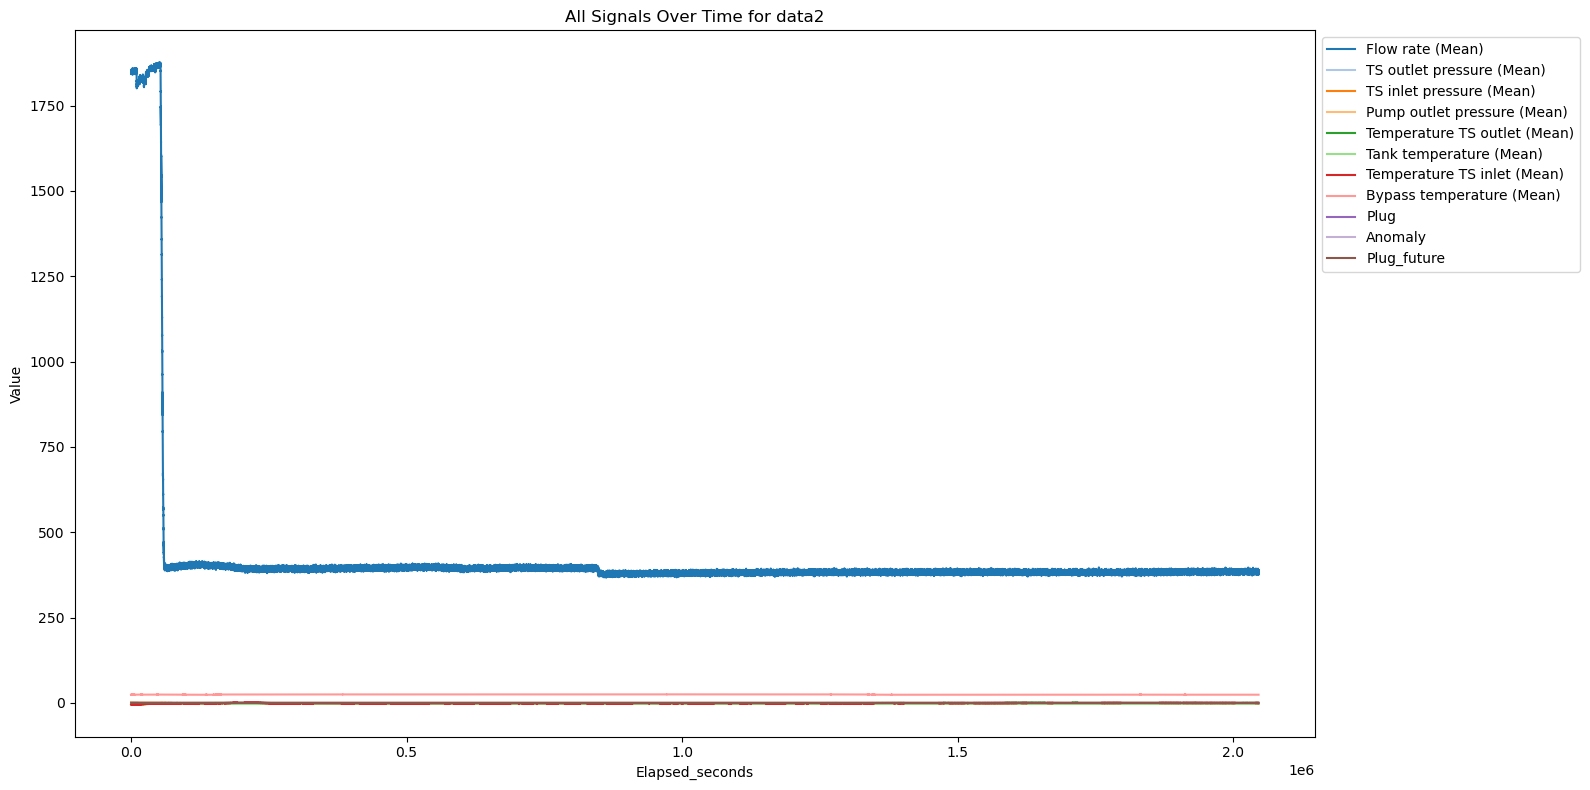

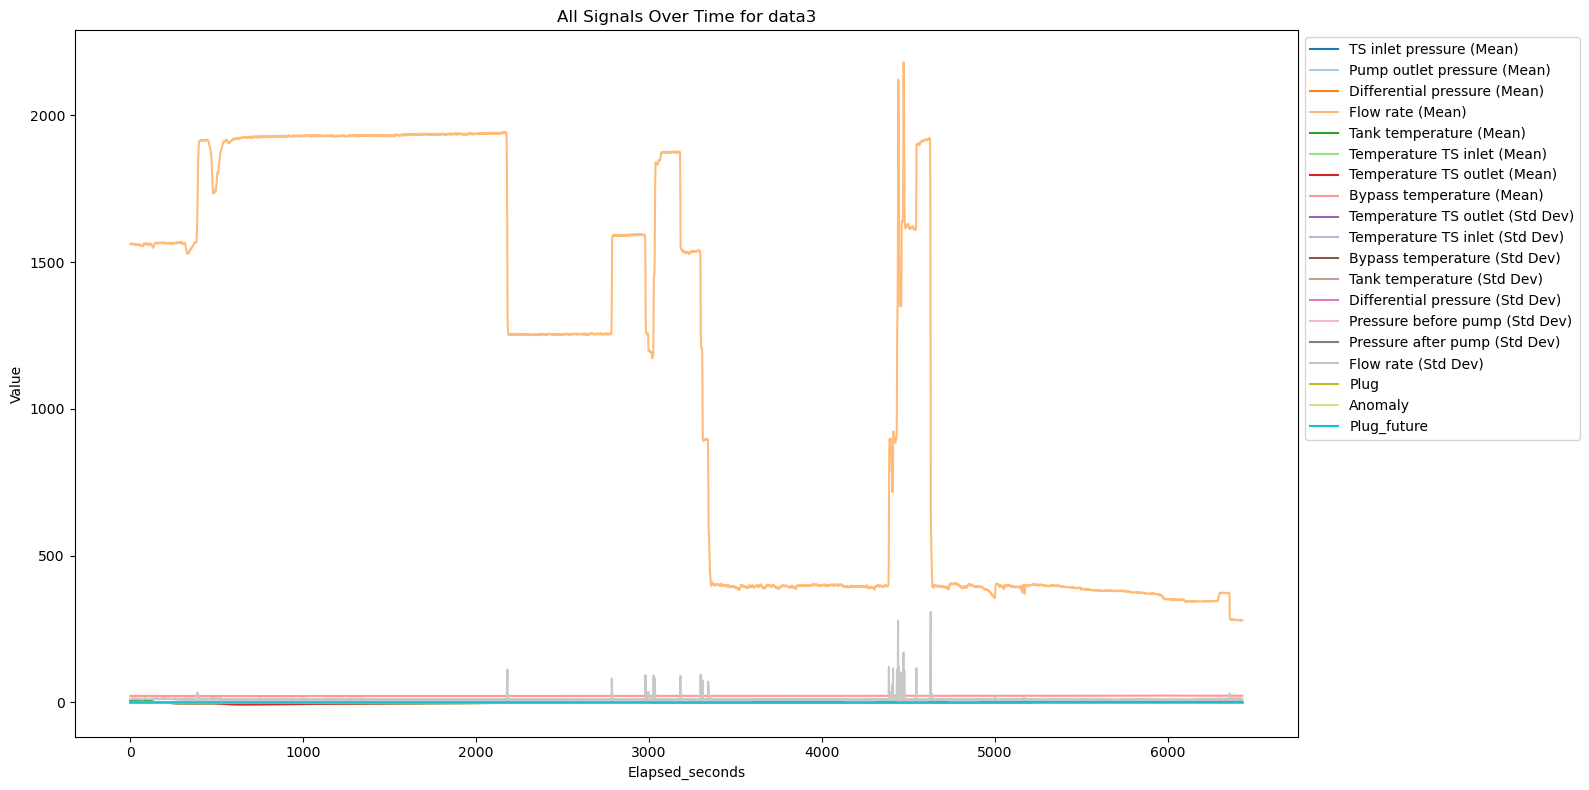

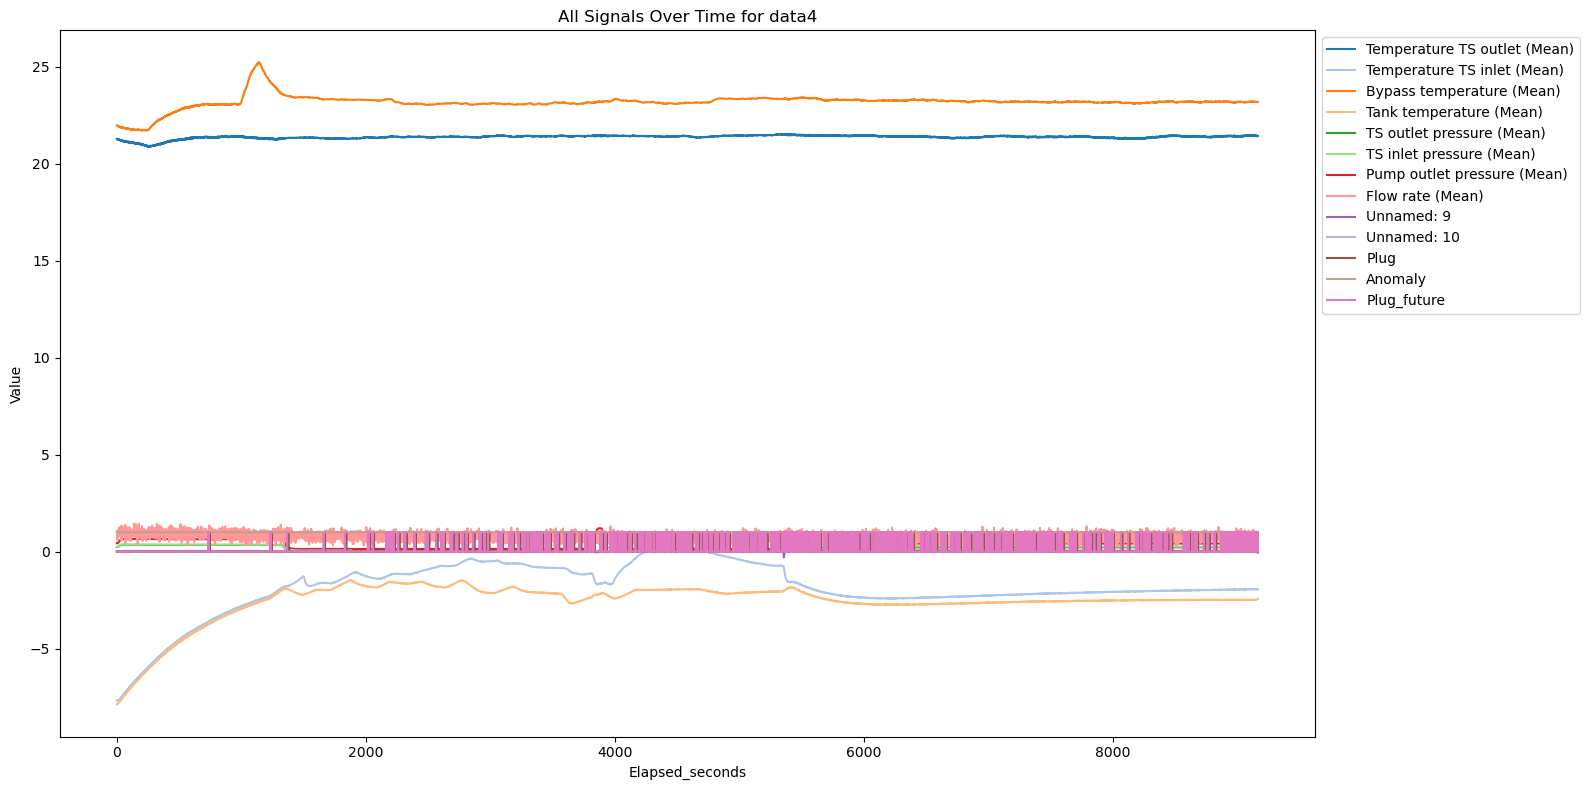

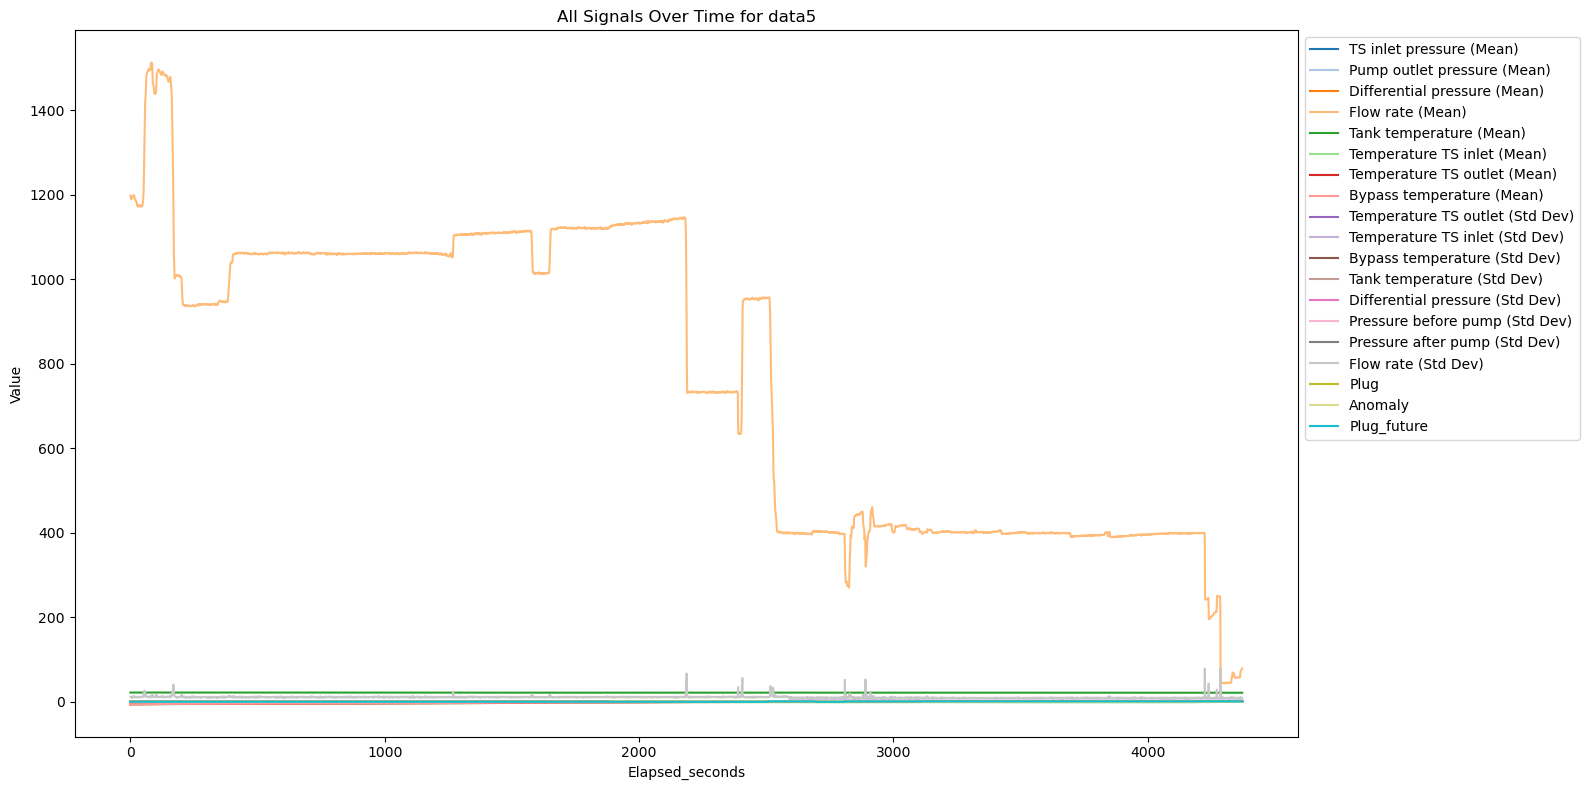

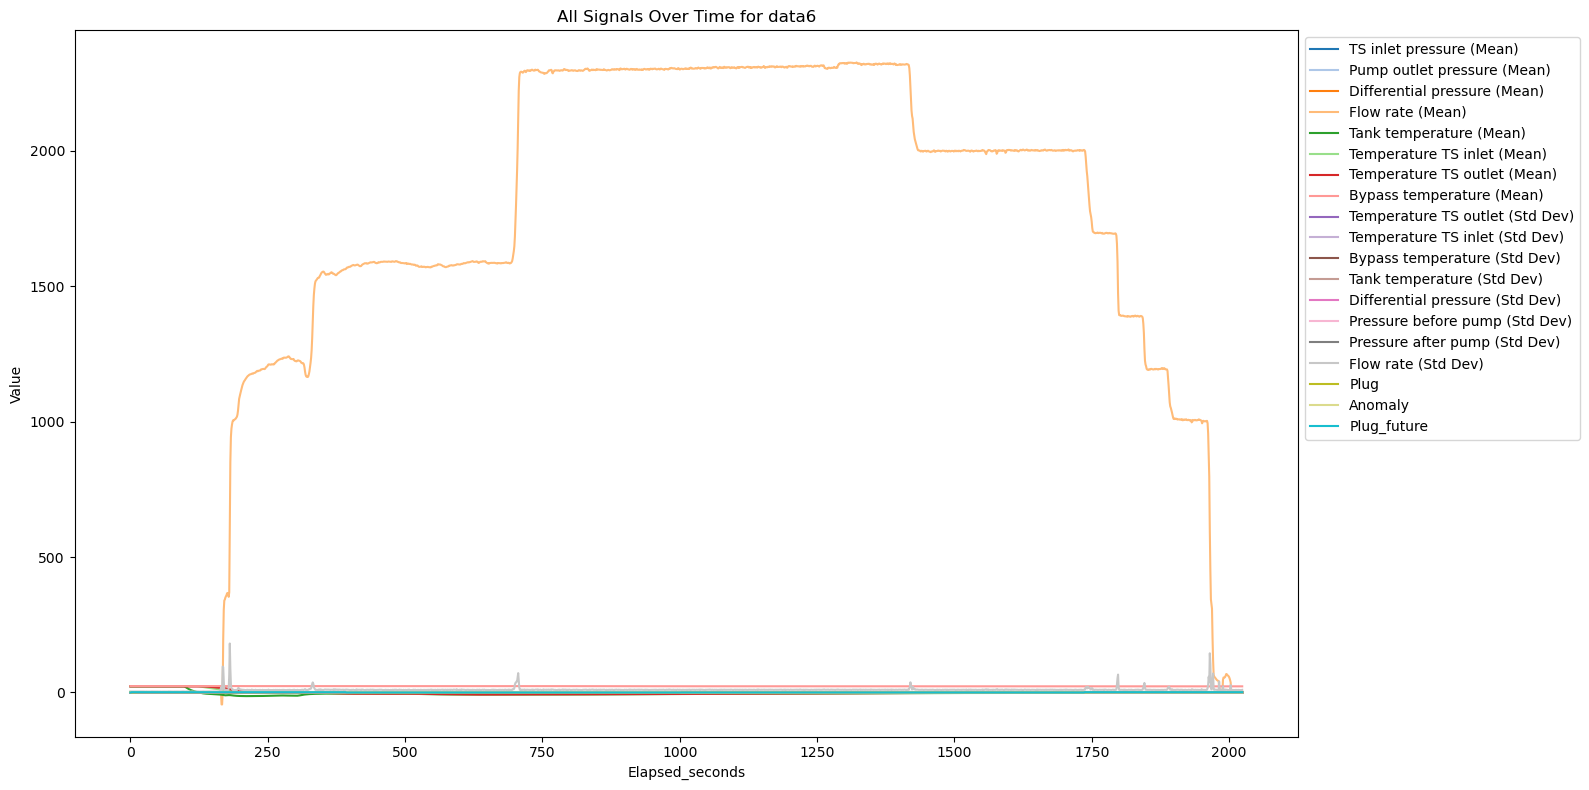

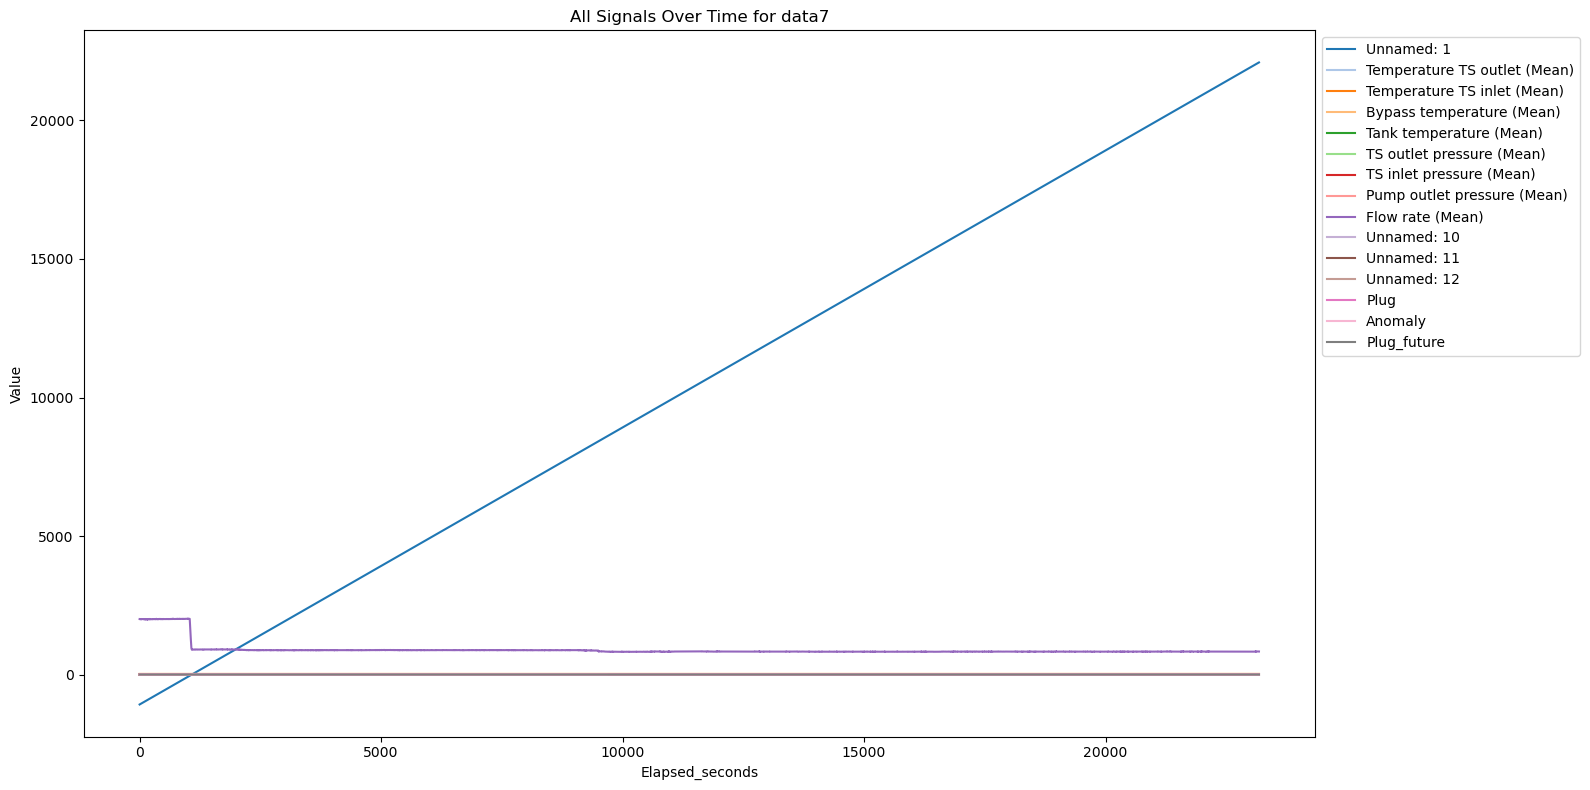

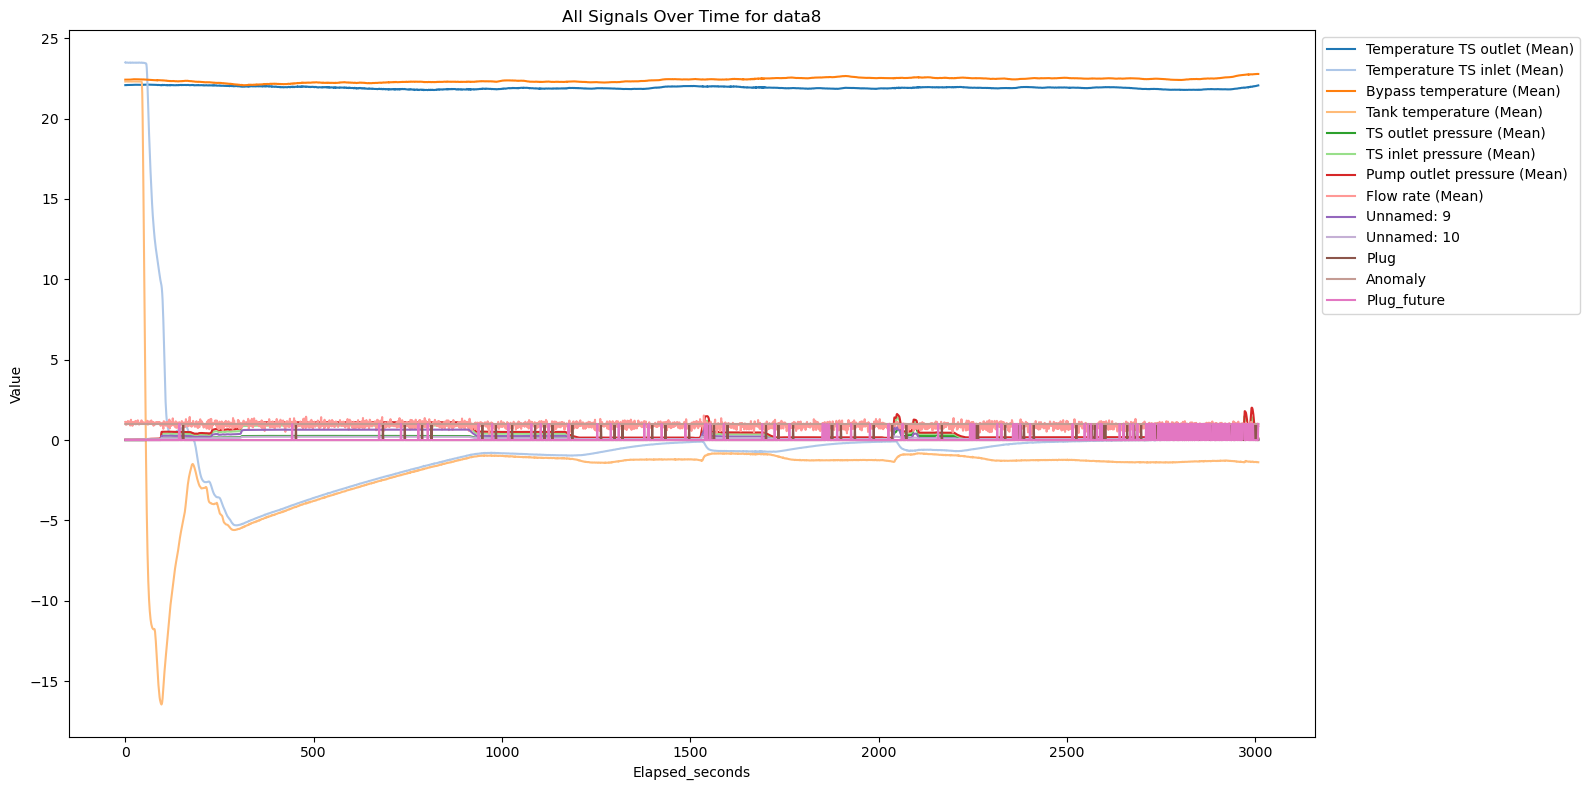

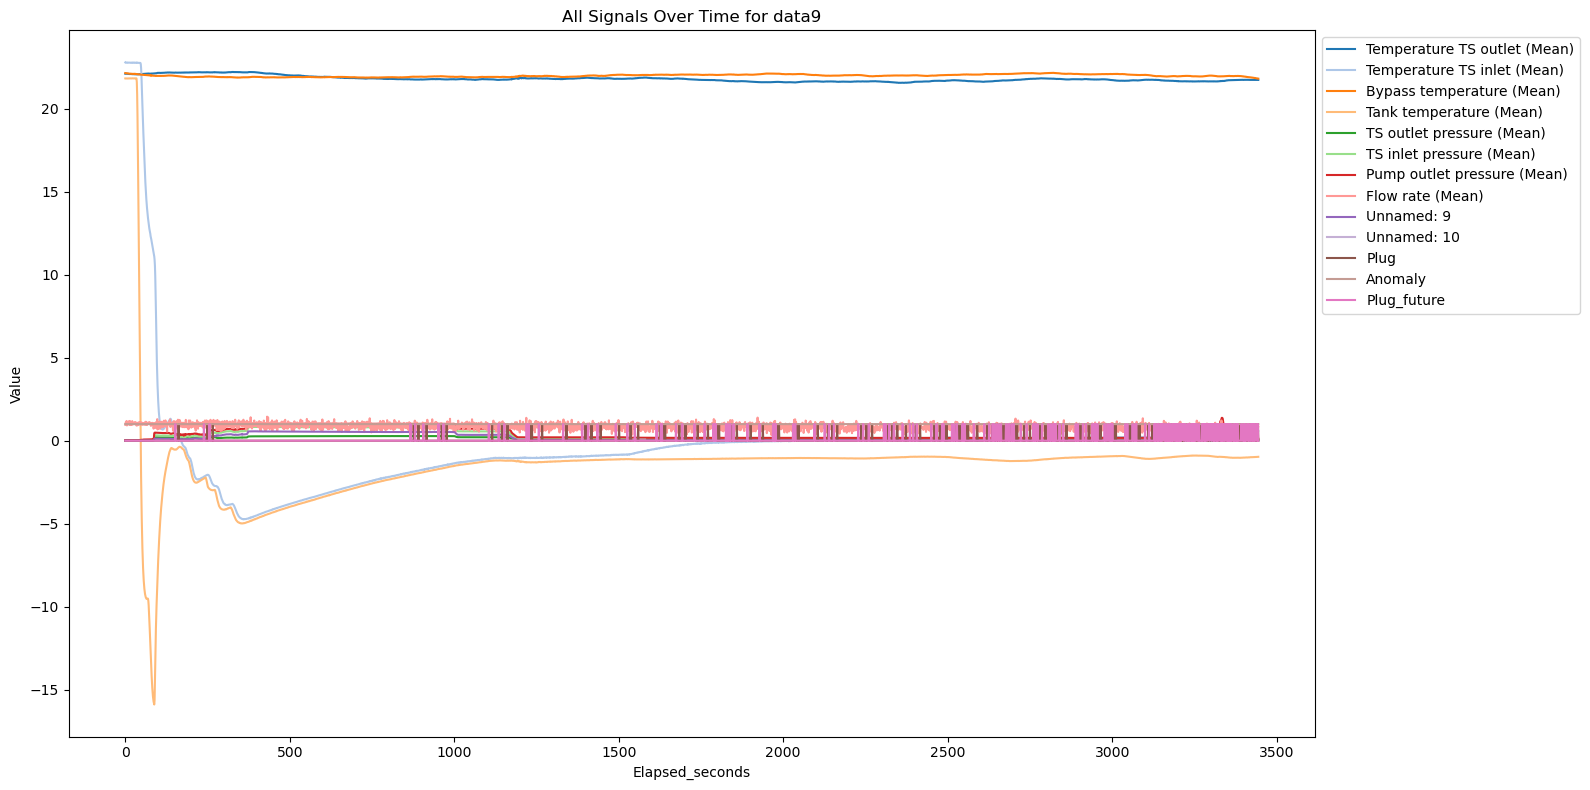

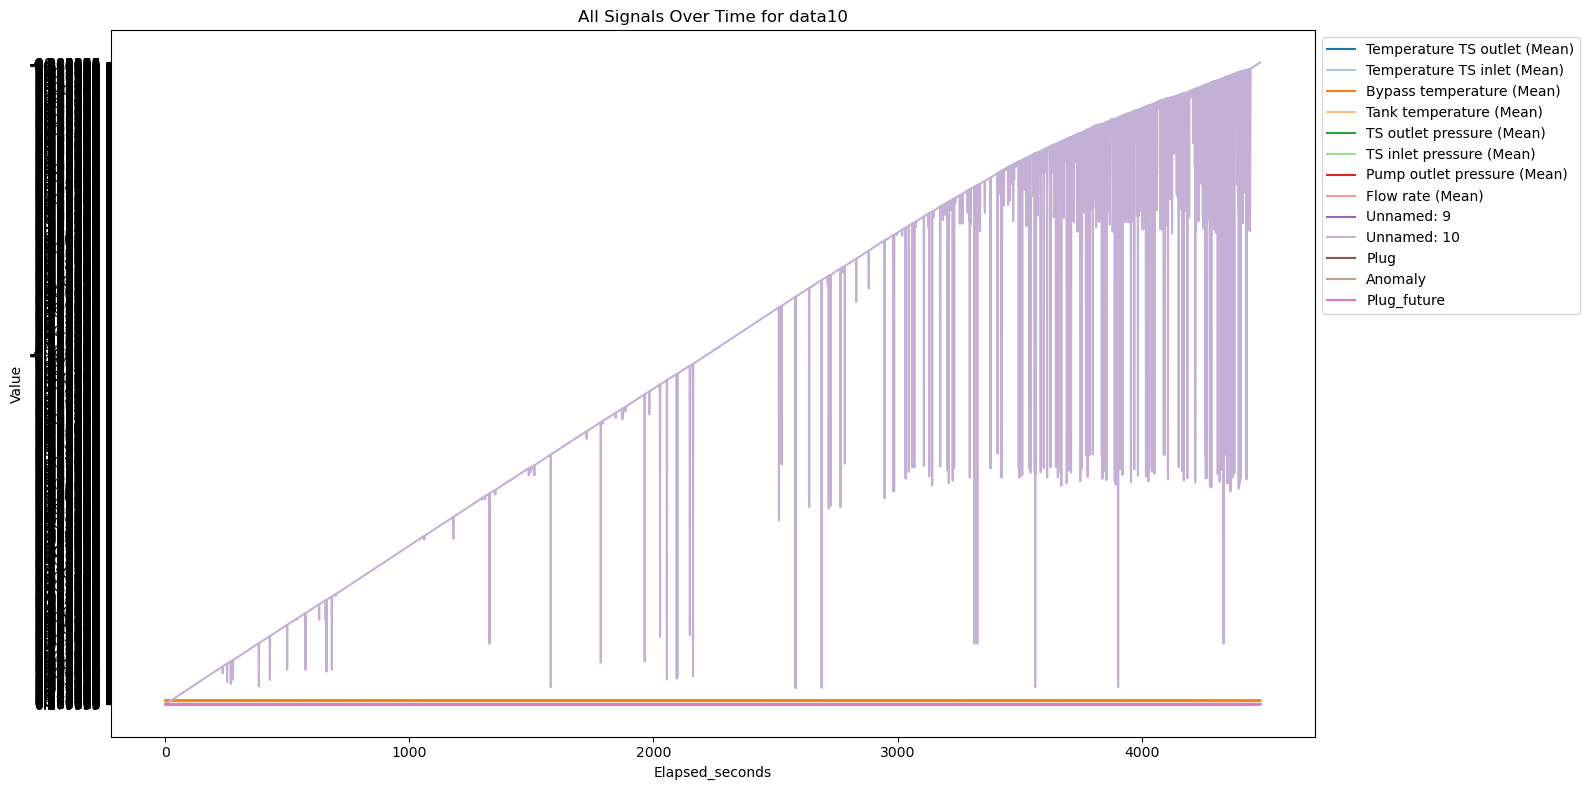

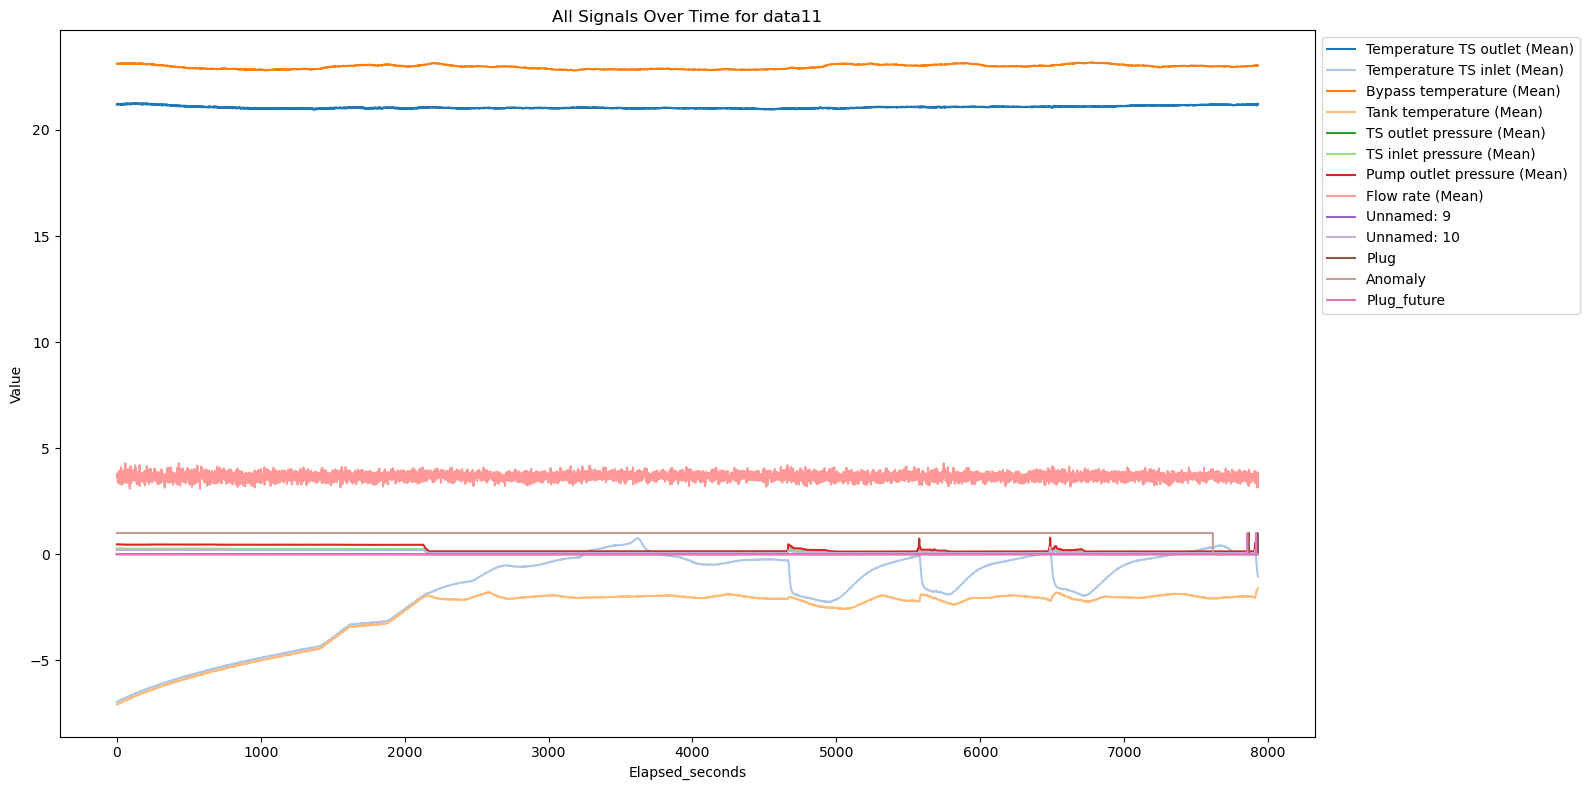

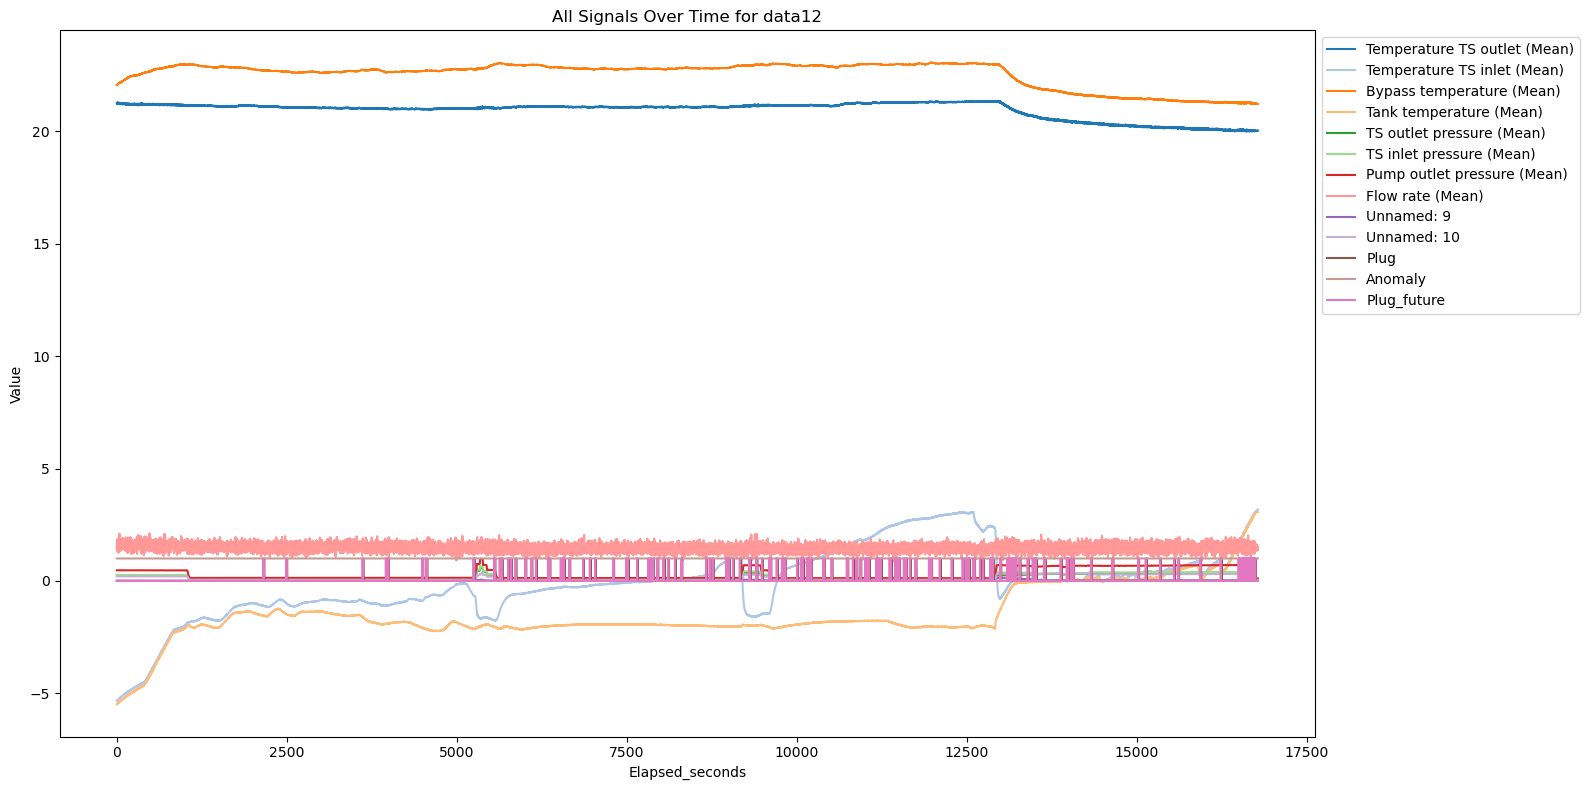

Saved plots to flow_pressure_drop_temp_plots.pdf


In [11]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.axes import Axes

output_pdf = "flow_pressure_drop_temp_plots.pdf"
with PdfPages(output_pdf) as pdf:
    for key, dataset in datasets.items():
        before = set(plt.get_fignums())
        res = dv.plot_flow_pressure_drop_temp(dataset, name=key)
        after = set(plt.get_fignums())

        figs = []

        # If the function returned a Figure or Axes, include it/them
        if isinstance(res, Figure):
            figs.append(res)
        elif isinstance(res, Axes):
            figs.append(res.figure)
        elif isinstance(res, (list, tuple)):
            for item in res:
                if isinstance(item, Figure):
                    figs.append(item)
                elif isinstance(item, Axes):
                    figs.append(item.figure)

        # include any new pyplot figures created during the call
        new_nums = sorted(after - before)
        for num in new_nums:
            figs.append(plt.figure(num))

        # fallback to any current figures
        if not figs:
            for num in plt.get_fignums():
                figs.append(plt.figure(num))

        # final fallback to gcf
        if not figs:
            figs = [plt.gcf()]

        # deduplicate figures
        unique = []
        seen = set()
        for f in figs:
            if id(f) not in seen:
                seen.add(id(f))
                unique.append(f)

        for fig in unique:
            try:
                fig.canvas.draw()
            except Exception:
                pass
            pdf.savefig(fig)
            plt.close(fig)

print(f"Saved plots to {output_pdf}")